Importing all the necessary libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Load the data as df

In [157]:
df = pd.read_csv('gld_price_data.csv')

Exploratory Data Analysis (EDA)

In [158]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [160]:
df.isna().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [161]:
df.duplicated().sum()

np.int64(0)

In [162]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


 Drop the Date Column


In [163]:
df.drop(columns=['Date'],inplace=True)
df.head(3)

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.180,1.471692
1,1447.160034,85.570000,78.370003,15.285,1.474491
2,1411.630005,85.129997,77.309998,15.167,1.475492


Correlation Heatmap

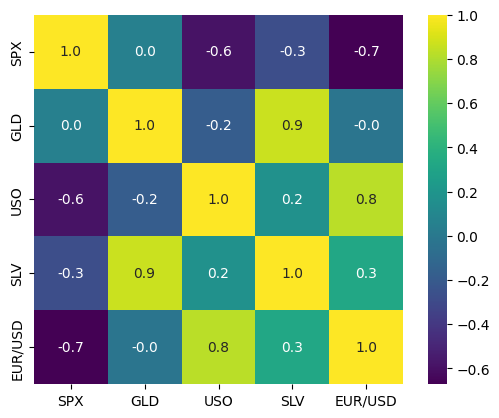

In [164]:
sns.heatmap(df.corr(),annot=True,cbar=True,square=True,fmt='.1f',cmap='viridis')
plt.show()

Correlation with the GLD column

In [165]:
df.corr().GLD

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64

Distribution Plot of GLD

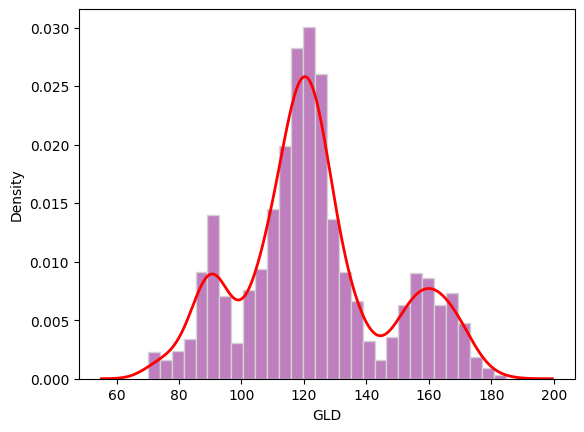

In [177]:
sns.histplot(df['GLD'], stat='density', bins=30, color='purple',alpha=.5,edgecolor='lightgrey')
sns.kdeplot(df['GLD'], color='red', linewidth=2)
plt.show()

Splitting the predictor and target columns

In [167]:
x=df.drop(columns='GLD')
y=df['GLD']

In [168]:
x.head()

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492
3,1416.180054,75.500000,15.053,1.468299
4,1390.189941,76.059998,15.590,1.557099


In [169]:
y.head()

0    84.860001
1    85.570000
2    85.129997
3    84.769997
4    86.779999
Name: GLD, dtype: float64

Generating train and test data

In [170]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=42)

Splits data into 80% training and 20% testing. random_state=42 ensures reproducibility.

Model Training by Random Forest Regressor

In [171]:
model= RandomForestRegressor(n_estimators=100)

Builds and trains a Random Forest — an ensemble of 100 decision trees. Each tree learns slightly different patterns; their average forms the final prediction.

In [172]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [173]:
y_prediction=model.predict(x_test)

In [174]:
print(y_prediction)

[122.50939991 130.34810304 127.71839993  96.88979757 119.18580066
 114.6075997  124.8897012  117.68349927 108.05990113  98.48509938
  95.53679942 167.59989779 148.23440122 116.25600077 171.01210123
  85.01790013 123.14739853 109.50909737 113.36450048 131.46580327
 124.29869893 113.7759006  116.01560078 108.81669997 108.53350122
 125.7825997  119.4280998  112.67119895 113.44380138 125.59729909
 146.23160146  89.54189973 167.6854004  113.79939909 108.40180089
 120.08060069 141.79959889 161.20560083 174.46019772 153.05090096
 119.59830098 113.64040003 121.31529959 113.6705996  122.07450019
 107.9392008   88.34029885 114.4801992  129.80360259 117.82390111
 103.78060013 129.68240286 107.17019824 160.31910372 131.6462
 118.34609981 146.95300104 135.36010163  95.67960081 124.45500159
 115.20739842  86.28490116 104.31049882 114.05980095  84.18899911
 122.32130015 116.51949911 113.54270197 165.52920343  92.25080013
  80.31590111 160.99670062 158.55480284 107.01379993 148.09680178
 109.77829742 

Calculating R-squared score

In [175]:
r2=metrics.r2_score(y_test,y_prediction)
print('The value of R-squared is:',r2)

The value of R-squared is: 0.9907190840152165


R² (coefficient of determination) measures how well the model explains variance in gold prices. A score close to 1.0 is excellent and R-squared score of our model is .99 which indicates our model is good. 

Comparing the actual and predicted data using a plot

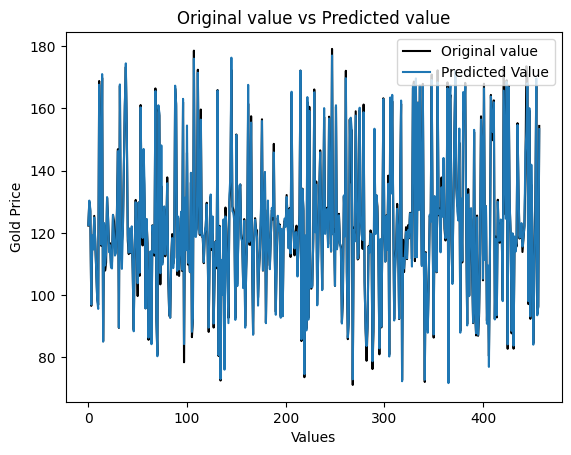

In [176]:
y_test=list(y_test)
plt.plot(y_test,color='black',label='Original value')
plt.plot(y_prediction,label='Predicted Value')
plt.title('Original value vs Predicted value')
plt.legend(loc='upper right')
plt.xlabel('Values')
plt.ylabel('Gold Price')
plt.show()